In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [2]:
import sys
import os

sys.path.append(os.path.abspath("../scripts"))

In [3]:
import sys
!{sys.executable} -m pip install pymysql

In [4]:
import sys
!{sys.executable} -m pip install plotly

In [5]:
from database import get_engine

engine = get_engine()

print("✅ Database Connected Successfully!")

✅ Database Connected Successfully!


In [6]:
import pandas as pd

customers = pd.read_sql("SELECT * FROM customers", engine)
orders = pd.read_sql("SELECT * FROM orders", engine)
payments = pd.read_sql("SELECT * FROM order_payments", engine)
order_items = pd.read_sql("SELECT * FROM order_items", engine)
products = pd.read_sql("SELECT * FROM products", engine)
reviews = pd.read_sql("SELECT * FROM order_reviews", engine)
sellers = pd.read_sql("SELECT * FROM sellers", engine)
categories = pd.read_sql("SELECT * FROM category_translation", engine)

print("✅ All tables loaded successfully!")

✅ All tables loaded successfully!


In [7]:
summary = pd.DataFrame({
    "Dataset": [
        "Customers",
        "Orders",
        "Payments",
        "Order Items",
        "Products",
        "Reviews",
        "Sellers",
        "Categories"
    ],
    "Rows": [
        customers.shape[0],
        orders.shape[0],
        payments.shape[0],
        order_items.shape[0],
        products.shape[0],
        reviews.shape[0],
        sellers.shape[0],
        categories.shape[0]
    ],
    "Columns": [
        customers.shape[1],
        orders.shape[1],
        payments.shape[1],
        order_items.shape[1],
        products.shape[1],
        reviews.shape[1],
        sellers.shape[1],
        categories.shape[1]
    ]
})

summary

,Dataset,Rows,Columns
0,Customers,99441,5
1,Orders,99441,8
2,Payments,103886,5
3,Order Items,112650,7
4,Products,32951,9
5,Reviews,99224,7
6,Sellers,3095,4
7,Categories,71,2


In [8]:
def inspect_dataset(df, name):
    print("=" * 70)
    print(f"{name.upper()}")
    print("=" * 70)

    print(f"Shape: {df.shape}")
    print()

    print("Data Types")
    display(df.dtypes.to_frame("Data Type"))

    print("\nMissing Values")
    display(df.isnull().sum().to_frame("Missing Values"))

    print(f"\nDuplicate Rows: {df.duplicated().sum()}")

    print("\nFirst Five Rows")
    display(df.head())

    print("\nSummary Statistics")
    display(df.describe(include="all"))

In [9]:
inspect_dataset(customers, "Customers")
inspect_dataset(orders, "Orders")
inspect_dataset(payments, "Payments")
inspect_dataset(order_items, "Order Items")
inspect_dataset(products, "Products")
inspect_dataset(reviews, "Reviews")
inspect_dataset(sellers, "Sellers")
inspect_dataset(categories, "Category Translation")

CUSTOMERS
Shape: (99441, 5)

Data Types


,Data Type
customer_id,object
customer_unique_id,object
customer_zip_code_prefix,int64
customer_city,object
customer_state,object



Missing Values


,Missing Values
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



Duplicate Rows: 0

First Five Rows


...

,Missing Values
product_category_name,0
product_category_name_english,0



Duplicate Rows: 0

First Five Rows


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



Summary Statistics


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,relogios_presentes,christmas_supplies
freq,1,1


In [10]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Payments": payments,
    "Order Items": order_items,
    "Products": products,
    "Reviews": reviews,
    "Sellers": sellers,
    "Categories": categories
}

missing_summary = []

for name, df in datasets.items():
    total_missing = df.isnull().sum().sum()
    missing_pct = round(
        (df.isnull().sum().sum() / df.size) * 100,
        2
    )

    missing_summary.append({
        "Dataset": name,
        "Missing Values": total_missing,
        "Missing (%)": missing_pct
    })

missing_df = pd.DataFrame(missing_summary)

missing_df

,Dataset,Missing Values,Missing (%)
0,Customers,0,0.00
1,Orders,4908,0.62
2,Payments,0,0.00
3,Order Items,0,0.00
4,Products,2448,0.83
5,Reviews,145903,21.01
6,Sellers,0,0.00
7,Categories,0,0.00


# Data Overview & Quality Assessment

### Observations

- Successfully loaded all datasets from the MySQL database.
- The dataset dimensions align with the ETL validation results.
- Most tables have no duplicate rows after preprocessing.
- Missing values are mainly associated with delivery timestamps for cancelled or undelivered orders.
- Data quality is sufficient for exploratory data analysis and visualization.

Feature Engineering


In [11]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])


In [12]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [13]:
orders["Purchase Year"] = orders["order_purchase_timestamp"].dt.year

orders["Purchase Month"] = orders["order_purchase_timestamp"].dt.month

orders["Purchase Month Name"] = orders["order_purchase_timestamp"].dt.month_name()

orders["Purchase Quarter"] = orders["order_purchase_timestamp"].dt.quarter

orders["Purchase Day"] = orders["order_purchase_timestamp"].dt.day_name()

In [14]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Month Name,Purchase Quarter,Purchase Day
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,4,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,July,3,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,August,3,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,November,4,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,February,1,Tuesday


In [15]:
orders["Delivery Days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days


orders["Estimated Delivery Days"] = (
    orders["order_estimated_delivery_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders["Delay Days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [16]:
orders["Late Delivery"] = np.where(
    orders["Delay Days"] > 0,
    "Yes",
    "No"
)
orders["Late Delivery"].value_counts()

No     92906
Yes     6535
Name: Late Delivery, dtype: int64

In [17]:
payment_summary = (
    payments
    .groupby("order_id", as_index=False)
    .agg(
        Total_Order_Value=("payment_value", "sum"),
        Payment_Count=("payment_sequential", "max")
    )
)

In [18]:
orders = orders.merge(
    payment_summary,
    on="order_id",
    how="left"
)

In [19]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Purchase Year,Purchase Month,Purchase Month Name,Purchase Quarter,Purchase Day,Delivery Days,Estimated Delivery Days,Delay Days,Late Delivery,Total_Order_Value,Payment_Count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,4,Monday,8.0,15,-8.0,No,38.71,3.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,July,3,Tuesday,13.0,19,-6.0,No,141.46,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,August,3,Wednesday,9.0,26,-18.0,No,179.12,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,November,4,Saturday,13.0,26,-13.0,No,72.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,February,1,Tuesday,2.0,12,-10.0,No,28.62,1.0


In [20]:
orders[
[
"Delivery Days",
"Estimated Delivery Days",
"Delay Days",
"Late Delivery",
"Total_Order_Value"
]
].head()

,Delivery Days,Estimated Delivery Days,Delay Days,Late Delivery,Total_Order_Value
0,8.0,15,-8.0,No,38.71
1,13.0,19,-6.0,No,141.46
2,9.0,26,-18.0,No,179.12
3,13.0,26,-13.0,No,72.20
4,2.0,12,-10.0,No,28.62


Visualizations

SECTION 1 — Revenue Analysis

Chart 1 — Monthly Revenue Trend 📈
Business Question

How has revenue changed over time? Are there seasonal trends or periods of rapid growth?

In [21]:
monthly_revenue = (
    orders.groupby(
        orders["order_purchase_timestamp"].dt.to_period("M")
    )["Total_Order_Value"]
    .sum()
    .reset_index()
)

monthly_revenue["order_purchase_timestamp"] = (
    monthly_revenue["order_purchase_timestamp"].astype(str)
)

monthly_revenue.head()

,order_purchase_timestamp,Total_Order_Value
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


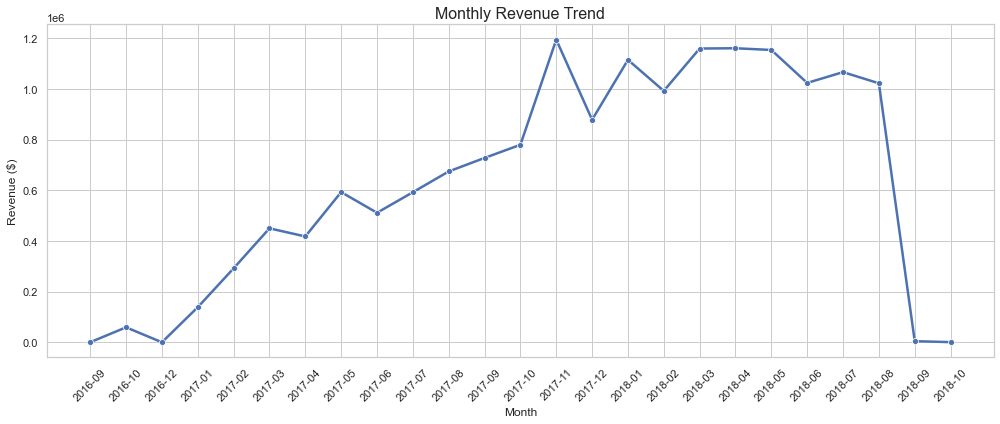

In [22]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_revenue,
    x="order_purchase_timestamp",
    y="Total_Order_Value",
    marker="o",
    linewidth=2.5
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Revenue ($)")

plt.tight_layout()

plt.show()

## Business Insight

- Revenue shows the month-to-month sales performance.
- Identify periods of rapid growth and seasonal slowdowns.
- Peaks may correspond to marketing campaigns or festive shopping seasons.

### Recommendation

Investigate high-performing months to understand successful business strategies and replicate them during slower periods.

Chart 2 — Monthly Order Volume

Business Question
How many orders were placed each month?

In [23]:
monthly_orders = (
    orders.groupby(
        orders["order_purchase_timestamp"].dt.to_period("M")
    )["order_id"]
    .count()
    .reset_index()
)

monthly_orders["order_purchase_timestamp"] = (
    monthly_orders["order_purchase_timestamp"].astype(str)
)

monthly_orders.head()

,order_purchase_timestamp,order_id
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


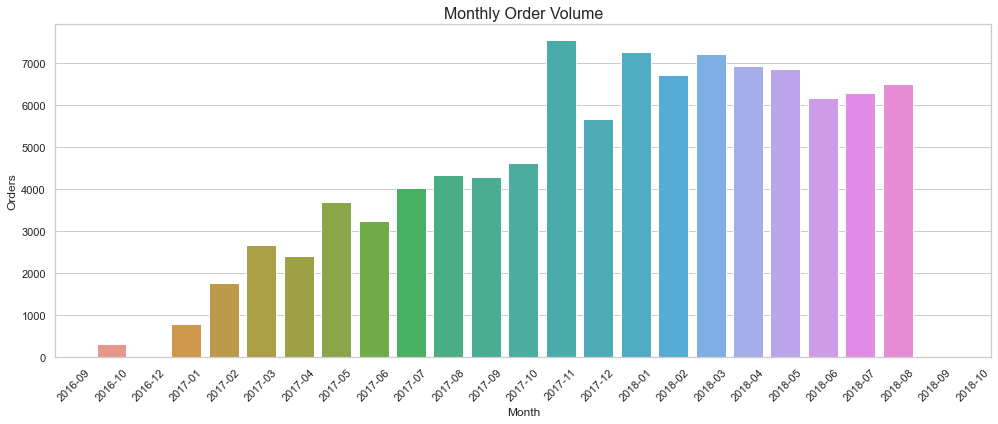

In [24]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=monthly_orders,
    x="order_purchase_timestamp",
    y="order_id"
)

plt.xticks(rotation=45)

plt.title("Monthly Order Volume", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

## Business Insight

- Order volume reflects customer demand over time.
- Compare this chart with the revenue trend.
- If revenue rises while order count remains stable, average order value may be increasing.

Chart 3 — Revenue Distribution

Business Question:

Are most orders low-value or high-value?

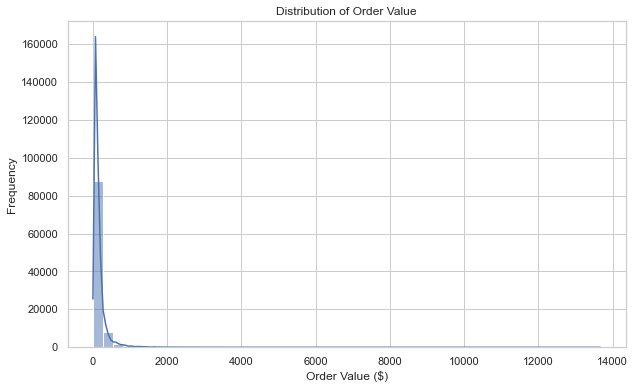

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    orders["Total_Order_Value"],
    bins=50,
    kde=True
)

plt.title("Distribution of Order Value")

plt.xlabel("Order Value ($)")

plt.ylabel("Frequency")

plt.show()

## Business Insight

- Most orders are expected to be concentrated in lower value ranges.
- A small number of high-value orders may contribute disproportionately to revenue.

### Recommendation

Introduce bundle offers and cross-selling strategies to increase average order value.

Chart 4 — Top 10 States by Revenue

Now let's answer a management question.

Which states contribute the most revenue?

In [26]:
state_revenue = (
    orders.merge(
        customers,
        on="customer_id"
    )
)

state_revenue = (
    state_revenue
    .groupby("customer_state")["Total_Order_Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

state_revenue


,customer_state,Total_Order_Value
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38
5,SC,623086.43
6,BA,616645.82
7,DF,355141.08
8,GO,350092.31
9,ES,325967.55


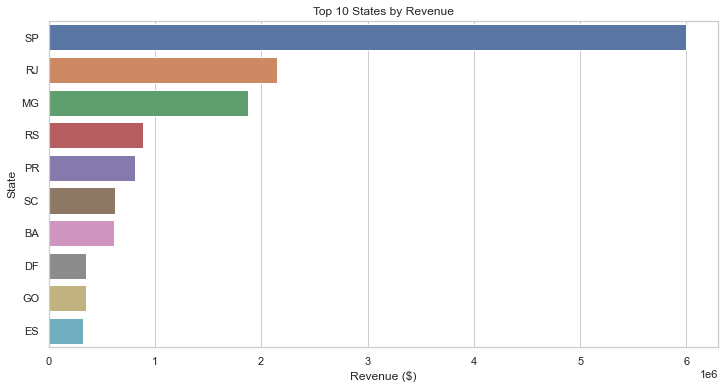

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_revenue,
    x="Total_Order_Value",
    y="customer_state"
)

plt.title("Top 10 States by Revenue")

plt.xlabel("Revenue ($)")

plt.ylabel("State")

plt.show()

## Business Insight

- Revenue is concentrated in a small number of states.
- These regions should be prioritized for marketing and inventory planning.

### Recommendation

Focus expansion efforts in high-performing states while identifying opportunities to improve sales in underperforming regions.

Customer Analysis

✔ Customer Spending Distribution
✔ Top 10 Customers
✔ Repeat vs One-Time Customers
✔ Customer Segmentation
✔ RFM Segment Distribution (Optional but Recommended)

Customer Spending Distribution
Business Question

How is customer spending distributed? Do we have many low-spending customers and a few high spenders?

In [28]:
customer_spending = (
    orders
    .groupby("customer_id")["Total_Order_Value"]
    .sum()
    .reset_index()
)

customer_spending.head()

,customer_id,Total_Order_Value
0,00012a2ce6f8dcda20d059ce98491703,114.74
1,000161a058600d5901f007fab4c27140,67.41
2,0001fd6190edaaf884bcaf3d49edf079,195.42
3,0002414f95344307404f0ace7a26f1d5,179.35
4,000379cdec625522490c315e70c7a9fb,107.01


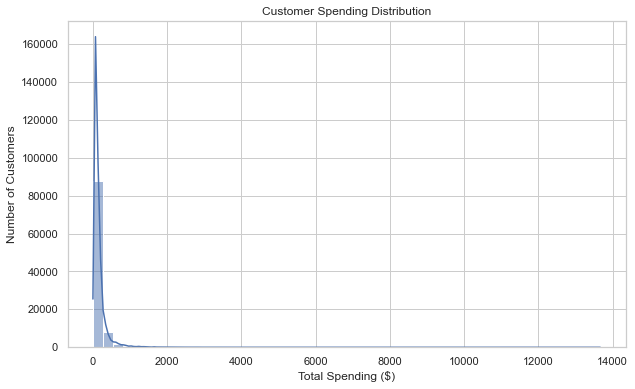

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    customer_spending["Total_Order_Value"],
    bins=50,
    kde=True
)

plt.title("Customer Spending Distribution")

plt.xlabel("Total Spending ($)")

plt.ylabel("Number of Customers")

plt.show()

## Business Insight

- Most customers contribute a relatively small amount of revenue.
- A small percentage of customers account for significantly higher spending.

### Recommendation

Identify high-value customers and implement loyalty or VIP programs to improve retention.

Top 10 Customers by Spending
Business Question

Who are our most valuable customers?

In [30]:
top_customers = (
    customer_spending
    .sort_values("Total_Order_Value", ascending=False)
    .head(10)
)

top_customers

,customer_id,Total_Order_Value
8546,1617b1357756262bfa56ab541c47bc16,13664.08
91985,ec5b2ba62e574342386871631fafd3fc,7274.88
77522,c6e2731c5b391845f6800c97401a43a9,6929.31
95124,f48d464a0baaea338cb25f816991ab1f,6922.21
24771,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66
2065,05455dfa7cd02f13d132aa7a6a9729c6,6081.54
86908,df55c14d1476a9a3467f131269c2477f,4950.34
87397,e0a2412720e9ea4f26c1ac985f6a7358,4809.44
14282,24bbf5fd2f2e1b359ee7de94defc4a15,4764.34
23932,3d979689f636322c62418b6346b1c6d2,4681.78


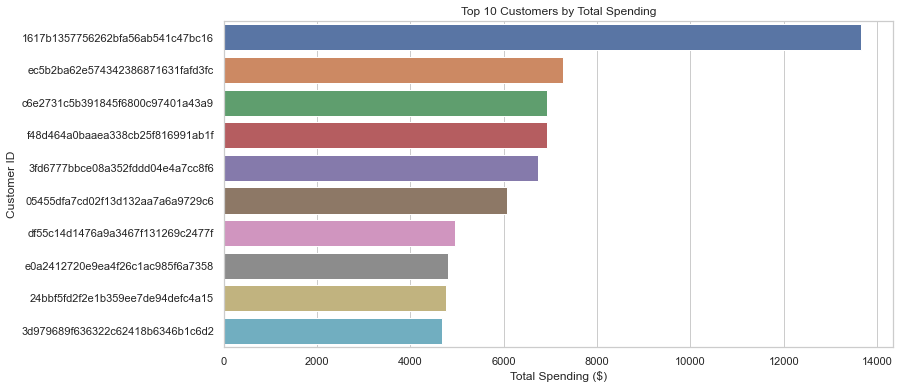

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_customers,
    x="Total_Order_Value",
    y="customer_id"
)

plt.title("Top 10 Customers by Total Spending")

plt.xlabel("Total Spending ($)")

plt.ylabel("Customer ID")

plt.show()

## Business Insight

- A small group of customers contributes a significant share of revenue.

### Recommendation

Provide exclusive offers and personalized recommendations to retain these high-value customers.

Repeat vs One-Time Customers
Business Question

How many customers purchase more than once?

In [32]:
customer_orders = (
    orders
    .groupby("customer_id")
    .size()
    .reset_index(name="Total Orders")
)

customer_orders["Customer Type"] = np.where(
    customer_orders["Total Orders"] > 1,
    "Repeat",
    "One-Time"
)

customer_orders.head()

,customer_id,Total Orders,Customer Type
0,00012a2ce6f8dcda20d059ce98491703,1,One-Time
1,000161a058600d5901f007fab4c27140,1,One-Time
2,0001fd6190edaaf884bcaf3d49edf079,1,One-Time
3,0002414f95344307404f0ace7a26f1d5,1,One-Time
4,000379cdec625522490c315e70c7a9fb,1,One-Time


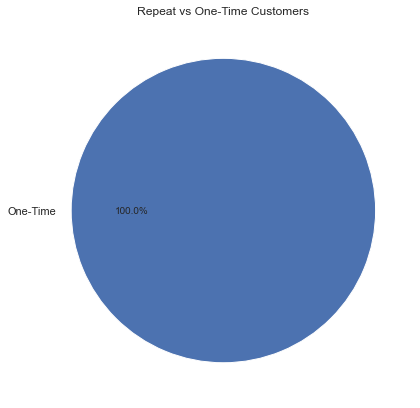

In [33]:
plt.figure(figsize=(7,7))

customer_orders["Customer Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Repeat vs One-Time Customers")

plt.show()

## Business Insight

- A high percentage of one-time customers suggests an opportunity to improve retention.

### Recommendation

Introduce personalized follow-up emails, discount coupons, and loyalty rewards to encourage repeat purchases.

Customer Segmentation

We'll use the same logic as in SQL.

In [34]:
customer_spending["Segment"] = pd.cut(
    customer_spending["Total_Order_Value"],
    bins=[0,200,500,1000,float("inf")],
    labels=[
        "New",
        "Regular",
        "Premium",
        "VIP"
    ]
)

customer_spending.head()

,customer_id,Total_Order_Value,Segment
0,00012a2ce6f8dcda20d059ce98491703,114.74,New
1,000161a058600d5901f007fab4c27140,67.41,New
2,0001fd6190edaaf884bcaf3d49edf079,195.42,New
3,0002414f95344307404f0ace7a26f1d5,179.35,New
4,000379cdec625522490c315e70c7a9fb,107.01,New


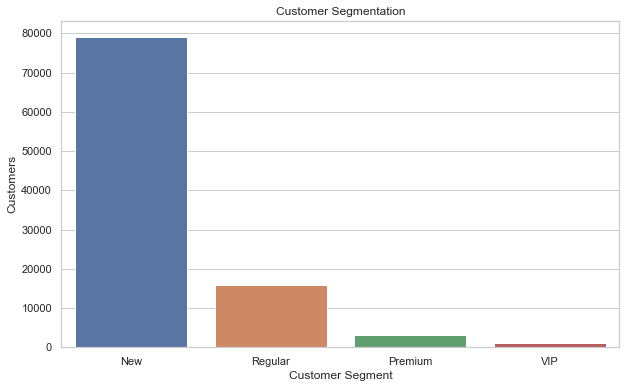

In [35]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=customer_spending,
    x="Segment",
    order=["New","Regular","Premium","VIP"]
)

plt.title("Customer Segmentation")

plt.xlabel("Customer Segment")

plt.ylabel("Customers")

plt.show()

## Business Insight

- Most customers belong to the New or Regular segment.
- Premium and VIP customers are fewer but generate a large portion of revenue.

### Recommendation

Develop targeted retention campaigns to move customers into higher-value segments.

Product Analysis

✔ Top 10 Product Categories by Revenue
✔ Top 10 Categories by Units Sold
✔ Average Product Price by Category
✔ Average Freight Cost by Category
✔ Average Review Score by Category

In [36]:
product_revenue = (
    order_items
    .merge(products, on="product_id")
    .merge(categories, on="product_category_name", how="left")
)

product_revenue["product_category_name_english"] = (
    product_revenue["product_category_name_english"]
    .fillna("Unknown")
)

category_revenue = (
    product_revenue
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

category_revenue.head()

,product_category_name_english,price
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32


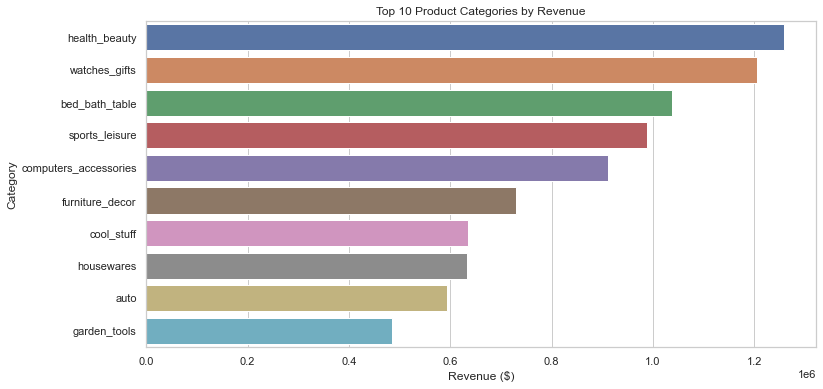

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_revenue,
    x="price",
    y="product_category_name_english"
)

plt.title("Top 10 Product Categories by Revenue")

plt.xlabel("Revenue ($)")

plt.ylabel("Category")

plt.show()

## Business Insight

- A small number of categories generate the majority of sales revenue.
- These categories should receive priority in inventory management and promotional campaigns.

### Recommendation

Increase stock availability and marketing investment for the highest-performing categories.

Top Categories by Units Sold
Business Question

Which categories sell the largest number of products?

In [38]:
category_orders = (
    product_revenue
    .groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Units Sold")
)

category_orders.head()

,product_category_name_english,Units Sold
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827


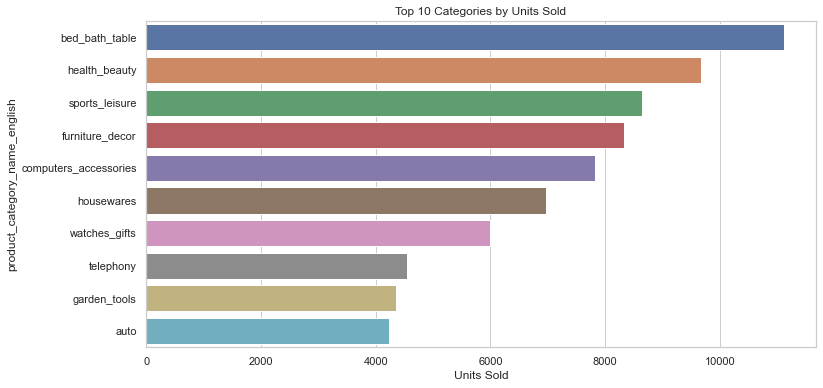

In [39]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_orders,
    x="Units Sold",
    y="product_category_name_english"
)

plt.title("Top 10 Categories by Units Sold")

plt.show()

## Business Insight

- High-volume categories indicate strong customer demand.
- Compare these results with revenue to distinguish high-volume from high-value categories.

Average Product Price by Category
Business Question

Which product categories are the most expensive on average?

In [40]:
avg_price = (
    product_revenue
    .groupby("product_category_name_english")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

avg_price.head()

,product_category_name_english,price
0,computers,1098.340542
1,small_appliances_home_oven_and_coffee,624.285658
2,home_appliances_2,476.124958
3,agro_industry_and_commerce,342.124858
4,musical_instruments,281.616000


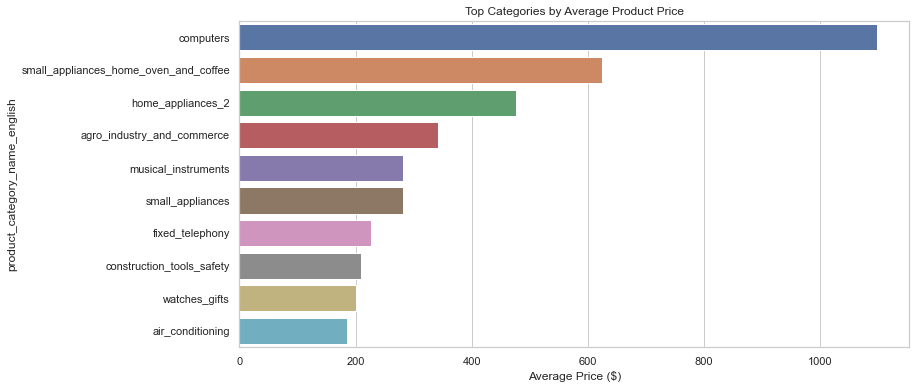

In [41]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=avg_price,
    x="price",
    y="product_category_name_english"
)

plt.title("Top Categories by Average Product Price")

plt.xlabel("Average Price ($)")

plt.show()

## Business Insight

- Premium-priced categories contribute higher revenue per transaction.
- Pricing strategy differs significantly across product categories.

Average Freight Cost by Category
Business Question

Which categories incur the highest shipping costs?

In [42]:
freight = (
    product_revenue
    .groupby("product_category_name_english")["freight_value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

freight.head()

,product_category_name_english,freight_value
0,computers,48.454680
1,home_appliances_2,44.538571
2,furniture_mattress_and_upholstery,42.906842
3,kitchen_dining_laundry_garden_furniture,42.702598
4,furniture_bedroom,42.497523


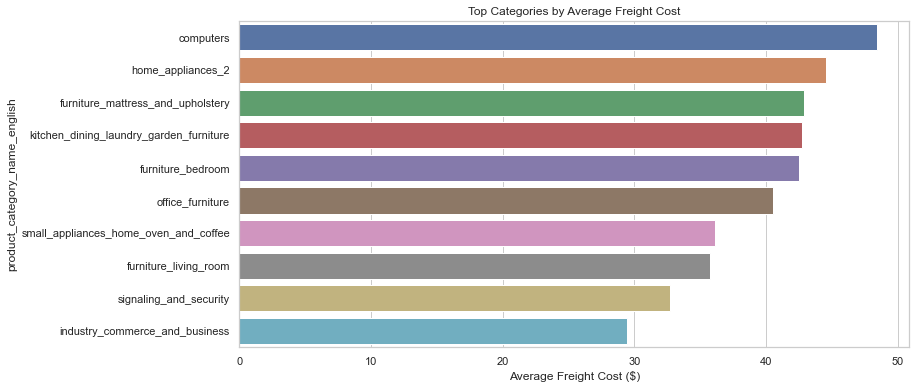

In [43]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=freight,
    x="freight_value",
    y="product_category_name_english"
)

plt.title("Top Categories by Average Freight Cost")

plt.xlabel("Average Freight Cost ($)")

plt.show()

## Business Insight

- Larger or heavier products tend to have higher freight costs.
- High logistics costs may reduce profit margins.

### Recommendation

Review shipping strategies and negotiate carrier rates for high-freight categories.

Average Review Score by Category
Business Question

Which product categories receive the highest customer satisfaction?

In [44]:
ratings = (
    product_revenue
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id"
    )
)

category_rating = (
    ratings
    .groupby("product_category_name_english")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

category_rating.head()

,product_category_name_english,review_score
0,cds_dvds_musicals,4.642857
1,fashion_childrens_clothes,4.500000
2,books_general_interest,4.446266
3,costruction_tools_tools,4.444444
4,flowers,4.419355


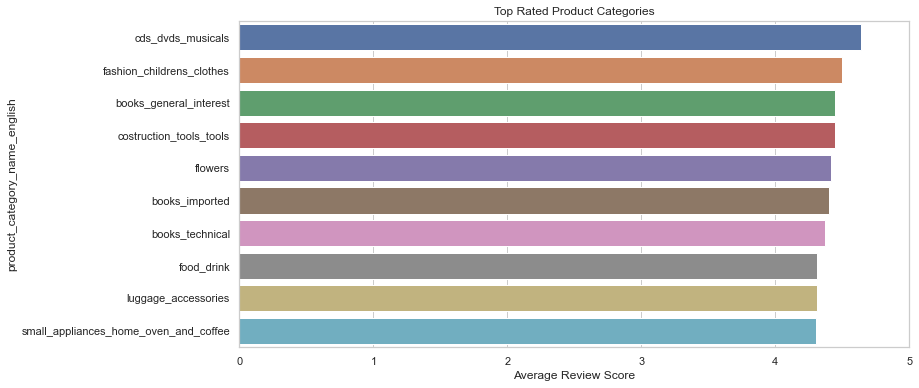

In [45]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_rating,
    x="review_score",
    y="product_category_name_english"
)

plt.title("Top Rated Product Categories")

plt.xlabel("Average Review Score")

plt.xlim(0,5)

plt.show()

## Business Insight

- Highly rated categories indicate strong customer satisfaction.
- Combining review scores with revenue helps identify products that are both profitable and well-received.

### Recommendation

Highlight top-rated categories in marketing campaigns and use them as benchmarks for improving lower-rated categories.

Delivery & Logistics Analysis

✔ Delivery Time Distribution
✔ On-Time vs Late Deliveries
✔ Delivery Time by State
✔ Delay Days Distribution
✔ Delay vs Review Score

Delivery Time Distribution
Business Question

How many days does it typically take to deliver an order?

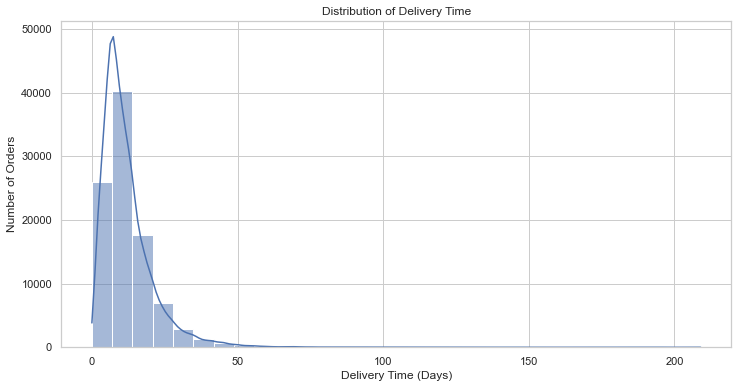

In [46]:
plt.figure(figsize=(12,6))

sns.histplot(
    orders["Delivery Days"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")

plt.xlabel("Delivery Time (Days)")

plt.ylabel("Number of Orders")

plt.show()

## Business Insight

- Most deliveries are completed within a consistent time window.
- Extremely long delivery times should be investigated.

### Recommendation

Identify operational bottlenecks causing delayed deliveries.

On-Time vs Late Deliveries
Business Question

What percentage of orders are delivered late?

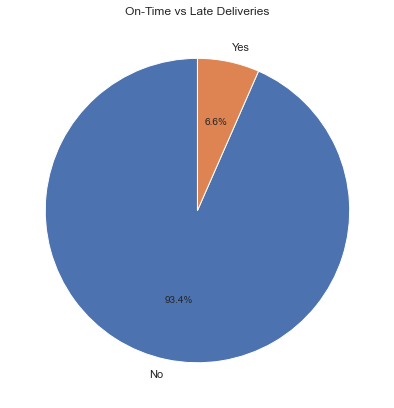

In [47]:
plt.figure(figsize=(7,7))

orders["Late Delivery"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("On-Time vs Late Deliveries")

plt.show()

## Business Insight

- A high percentage of on-time deliveries indicates efficient logistics.
- Even a small percentage of late deliveries can negatively impact customer satisfaction.

Average Delivery Time by State
Business Question

Which states experience the longest delivery times?

In [48]:
delivery_state = (
    orders
    .merge(customers, on="customer_id")
)

state_delivery = (
    delivery_state
    .groupby("customer_state")["Delivery Days"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

state_delivery.head()

,customer_state,Delivery Days
0,RR,28.975610
1,AP,26.731343
2,AM,25.986207
3,AL,24.040302
4,PA,23.316068


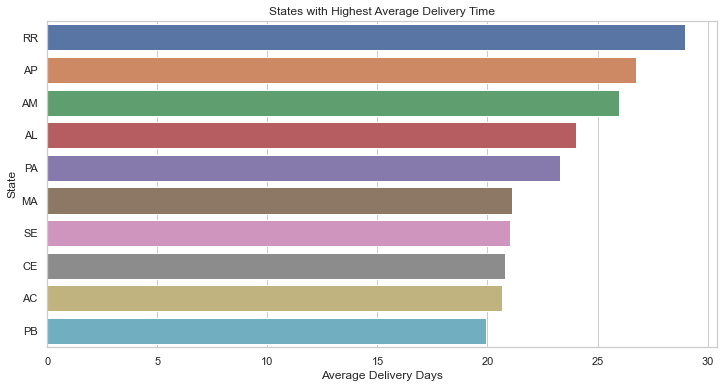

In [49]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_delivery,
    x="Delivery Days",
    y="customer_state"
)

plt.title("States with Highest Average Delivery Time")

plt.xlabel("Average Delivery Days")

plt.ylabel("State")

plt.show()

## Business Insight

- Certain regions consistently experience longer delivery times.
- Geographic challenges or logistics network limitations may contribute.

### Recommendation

Optimize warehouse placement and shipping routes for slower regions.

Delay Days Distribution
Business Question

How many days early or late are orders delivered?

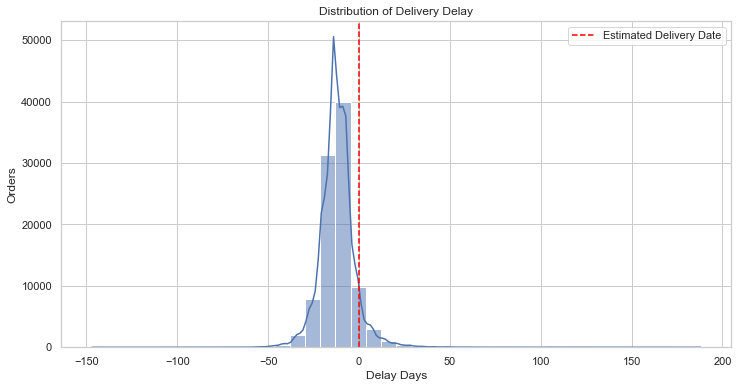

In [50]:
plt.figure(figsize=(12,6))

sns.histplot(
    orders["Delay Days"].dropna(),
    bins=40,
    kde=True
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="Estimated Delivery Date"
)

plt.legend()

plt.title("Distribution of Delivery Delay")

plt.xlabel("Delay Days")

plt.ylabel("Orders")

plt.show()

## Business Insight

- Negative values represent early deliveries.
- Positive values represent late deliveries.
- Understanding this distribution helps evaluate delivery reliability.

Delivery Delay vs Review Score
Business Question

Do delayed deliveries affect customer ratings?

In [51]:
delay_reviews = (
    orders[
        ["order_id", "Delay Days"]
    ]
    .merge(
        reviews[
            ["order_id", "review_score"]
        ],
        on="order_id"
    )
)

delay_reviews["Delay Bucket"] = pd.cut(
    delay_reviews["Delay Days"],
    bins=[-100,-1,5,100],
    labels=[
        "On Time / Early",
        "1–5 Days Late",
        "More than 5 Days Late"
    ]
)

delay_reviews.head()

,order_id,Delay Days,review_score,Delay Bucket
0,e481f51cbdc54678b7cc49136f2d6af7,-8.0,4,On Time / Early
1,53cdb2fc8bc7dce0b6741e2150273451,-6.0,4,On Time / Early
2,47770eb9100c2d0c44946d9cf07ec65d,-18.0,5,On Time / Early
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,5,On Time / Early
4,ad21c59c0840e6cb83a9ceb5573f8159,-10.0,5,On Time / Early


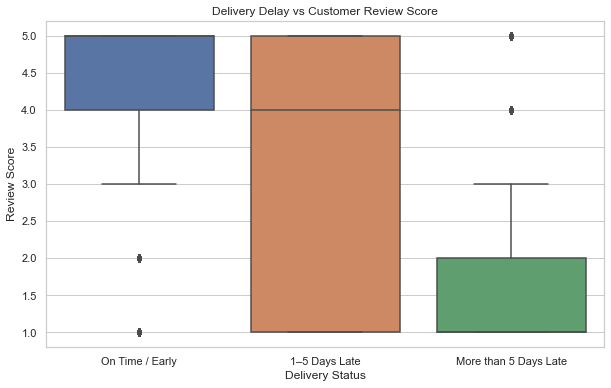

In [52]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=delay_reviews,
    x="Delay Bucket",
    y="review_score"
)

plt.title("Delivery Delay vs Customer Review Score")

plt.xlabel("Delivery Status")

plt.ylabel("Review Score")

plt.show()

## Business Insight

- Late deliveries are generally associated with lower customer ratings.
- Timely delivery plays a significant role in customer satisfaction.

### Recommendation

Prioritize reducing delivery delays to improve customer experience and reviews.

Review & Customer Satisfaction Analysis

✔ Review Score Distribution
✔ Average Rating by State
✔ Top Rated Product Categories
✔ Order Value vs Review Score
✔ Correlation Heatmap

Review Score Distribution
Business Question

How satisfied are customers overall?

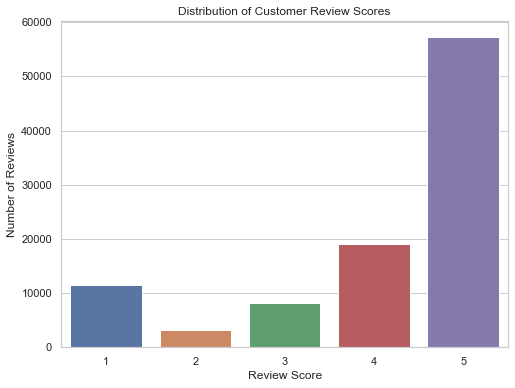

In [53]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=reviews,
    x="review_score"
)

plt.title("Distribution of Customer Review Scores")

plt.xlabel("Review Score")

plt.ylabel("Number of Reviews")

plt.show()

## Business Insight

- Review scores indicate the overall customer satisfaction level.
- A large proportion of 4- and 5-star reviews suggests positive customer experiences.

### Recommendation

Continue maintaining product and delivery quality while investigating reasons behind lower ratings.

Average Rating by State
Business Question

Which states have the happiest customers?

In [54]:
state_reviews = (
    reviews
    .merge(
        orders[["order_id","customer_id"]],
        on="order_id"
    )
    .merge(
        customers[["customer_id","customer_state"]],
        on="customer_id"
    )
)

avg_state_rating = (
    state_reviews
    .groupby("customer_state")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_state_rating.head()

,customer_state,review_score
0,AP,4.194030
1,AM,4.183673
2,PR,4.180032
3,SP,4.173951
4,MG,4.136172


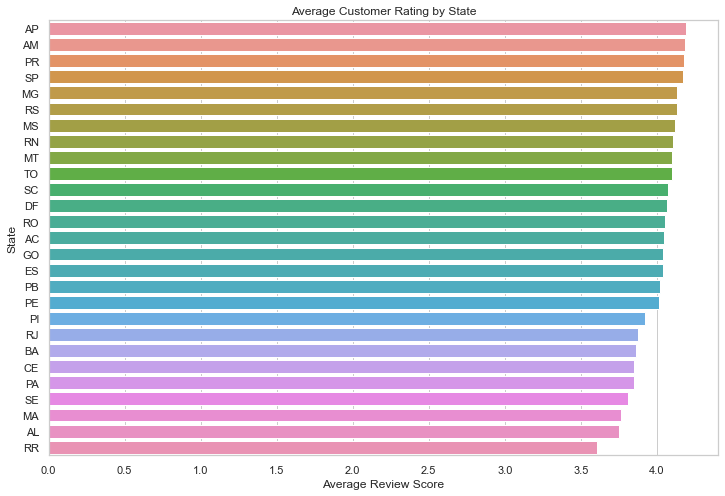

In [55]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=avg_state_rating,
    x="review_score",
    y="customer_state"
)

plt.title("Average Customer Rating by State")

plt.xlabel("Average Review Score")

plt.ylabel("State")

plt.show()

## Business Insight

- Customer satisfaction varies across different states.
- Lower-rated regions may indicate logistics or service issues.

### Recommendation

Investigate operational challenges in low-rated states.

Top Rated Product Categories
Business Question

Which product categories receive the highest customer ratings?

In [56]:
category_reviews = (
    order_items
    .merge(products, on="product_id")
    .merge(categories, on="product_category_name", how="left")
    .merge(reviews[["order_id","review_score"]], on="order_id")
)

category_rating = (
    category_reviews
    .groupby("product_category_name_english")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

category_rating.head()

,product_category_name_english,review_score
0,cds_dvds_musicals,4.642857
1,fashion_childrens_clothes,4.500000
2,books_general_interest,4.446266
3,costruction_tools_tools,4.444444
4,flowers,4.419355


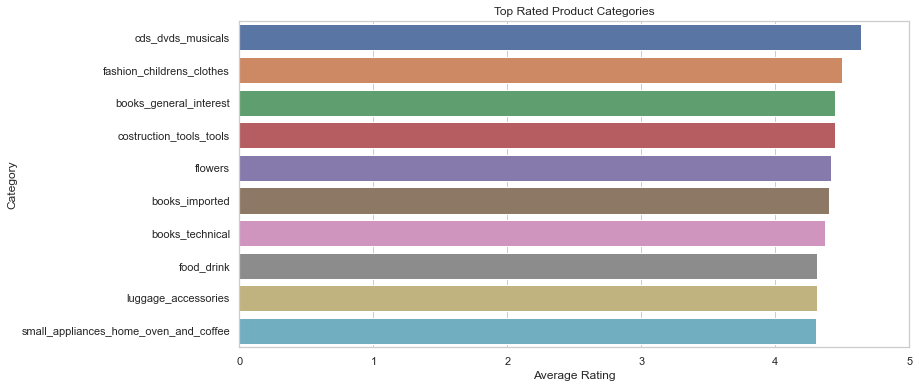

In [57]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_rating,
    x="review_score",
    y="product_category_name_english"
)

plt.title("Top Rated Product Categories")

plt.xlabel("Average Rating")

plt.ylabel("Category")

plt.xlim(0,5)

plt.show()

## Business Insight

- Highly rated categories demonstrate strong product quality and customer satisfaction.

### Recommendation

Promote these categories more aggressively and learn from them to improve lower-rated categories.

Order Value vs Review Score
Business Question

Do customers who spend more give better ratings?

In [58]:
review_value = (
    orders[["order_id","Total_Order_Value"]]
    .merge(
        reviews[["order_id","review_score"]],
        on="order_id"
    )
)

review_value.head()

,order_id,Total_Order_Value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,4
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,4
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,5
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,5
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,5


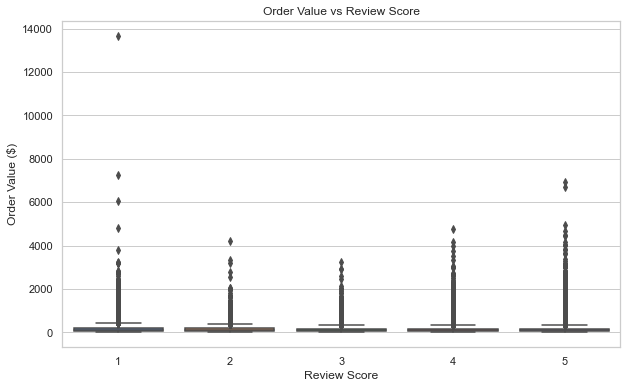

In [59]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=review_value,
    x="review_score",
    y="Total_Order_Value"
)

plt.title("Order Value vs Review Score")

plt.xlabel("Review Score")

plt.ylabel("Order Value ($)")

plt.show()

## Business Insight

- Customer satisfaction appears relatively independent of order value.
- High-value purchases still require excellent customer experience.

# Final Business Conclusions

## Key Findings

- Revenue is concentrated in a few product categories and customer regions.
- Most customers are one-time buyers, highlighting an opportunity to improve retention.
- Premium and VIP customers contribute disproportionately to total revenue.
- Delivery delays negatively impact customer review scores.
- Certain product categories consistently receive higher ratings, indicating strong customer satisfaction.

## Business Recommendations

1. Expand marketing efforts in high-performing states and categories.
2. Launch loyalty programs to increase repeat purchases.
3. Optimize logistics in regions with longer delivery times.
4. Focus on reducing late deliveries to improve customer satisfaction.
5. Promote top-rated product categories to drive future sales.